# BlackJAX Nested Slice Sampling for MWA AEE beam inference

This notebook explores **nested slice sampling (NSS)** as an alternative to the
custom tempered SMC + NUTS sampler used for the complex dipole-gain inference.

The motivation is the strongly multimodal posterior seen in the existing SMC
analysis. In particular, the posterior contains two favourable modes related by an
analytic conjugate-$180^\circ$-rotation symmetry, while the full parameter space
also appears to contain many poorer local basins.

Nested sampling approaches this problem differently from tempered SMC. Rather than
following

$$
p(\theta)\,\mathcal L(\theta)^\beta,\qquad \beta:0\rightarrow1,
$$

it maintains a population of live points drawn from the prior and repeatedly
replaces the lowest-likelihood points with new points constrained to have higher
likelihood. The posterior and evidence are reconstructed afterwards from the full
history of discarded points.

This first notebook is deliberately exploratory. The main questions are:

1. Can BlackJAX NSS recover both conjugate modes in a single run?
2. Are the recovered local mode locations consistent with the existing SMC results?
3. What relative posterior mass does NSS assign to the two symmetry branches?
4. Is the runtime competitive enough to consider NSS as the production sampler?
5. How sensitive are the answers to the number of live points, inner slice steps,
   deletion fraction, and stopping criterion?

The implementation below follows the current BlackJAX Sampling Book NSS interface
(`blackjax.nss`, `finalise`, `log_weights`, and `ns_sample`). It is intended for
BlackJAX 1.6.x or later.

References:

- [BlackJAX Sampling Book: Nested Sampling](https://blackjax-devs.github.io/sampling-book/algorithms/nested-sampling/)
- [BlackJAX nested-sampling API](https://blackjax-devs.github.io/blackjax/autoapi/blackjax/ns/index.html)


## 1. Imports and configuration

In [1]:
# MUST run before importing jax, blackjax, numpyro,
# or anything else that imports JAX.

import os

os.environ["XLA_FLAGS"] = (
    "--xla_force_host_platform_device_count=12"
)

import jax

print("JAX devices:", jax.devices())
print("CPU devices:", jax.devices("cpu"))
print("Number of CPU devices:", len(jax.devices("cpu")))

JAX devices: [CpuDevice(id=0), CpuDevice(id=1), CpuDevice(id=2), CpuDevice(id=3), CpuDevice(id=4), CpuDevice(id=5), CpuDevice(id=6), CpuDevice(id=7), CpuDevice(id=8), CpuDevice(id=9), CpuDevice(id=10), CpuDevice(id=11)]
CPU devices: [CpuDevice(id=0), CpuDevice(id=1), CpuDevice(id=2), CpuDevice(id=3), CpuDevice(id=4), CpuDevice(id=5), CpuDevice(id=6), CpuDevice(id=7), CpuDevice(id=8), CpuDevice(id=9), CpuDevice(id=10), CpuDevice(id=11)]
Number of CPU devices: 12


In [2]:
from pathlib import Path
import re

import numpy as np
import healpy as hp
import jax
import jax.numpy as jnp
import matplotlib.pyplot as plt
import cmasher as cmr
from matplotlib.colors import ListedColormap

from embers_passes import PassFile, chunk_passes, chunks_to_healpix_counts
from mwa_jaxbeam import aee_137mhz as aee

colors = cmr.pride(np.linspace(0.1, 0.8, 256))
prd = ListedColormap(colors, name="pride")
prd.set_under("white")

wfr_lin = cmr.get_sub_cmap(cmr.wildfire, 0.5, 1.0).with_extremes(under="w")

In [3]:
INPUT_PATH = Path("../passes/monotonic_concave_5hz_pval/S06XX_rf0XX_passes.h5")

POINTING = 0
CHUNK_INDEX = 0
CHUNK_DAYS = 200.0
NSIDE = 32
MIN_PIXEL_COUNTS = 3

N_DIPOLES = 16
dipoles = np.arange(N_DIPOLES)

# Priors retained from the SMC experiments.
DIRICHLET_ALPHA = 10.0
PHASE_PRIOR_STD_DEG = 10.0
PHASE_PRIOR_STD_RAD = np.deg2rad(PHASE_PRIOR_STD_DEG)
PHASE_KAPPA = 1.0 / PHASE_PRIOR_STD_RAD**2

print("Input:", INPUT_PATH)
print("NSIDE:", NSIDE)
print("Minimum samples per HEALPix pixel:", MIN_PIXEL_COUNTS)

Input: ../passes/monotonic_concave_5hz_pval/S06XX_rf0XX_passes.h5
NSIDE: 32
Minimum samples per HEALPix pixel: 3


In [4]:
def infer_tile_pol(path):
    match = re.search(r"(S\d{2})(XX|YY)", path.name, re.IGNORECASE)
    if match is None:
        raise ValueError(f"Could not infer tile/pol from {path.name!r}.")
    tile, pol = match.group(1).upper(), match.group(2).upper()
    return tile, pol, {"XX": 0, "YY": 1}[pol]

tile, pol_name, POL = infer_tile_pol(INPUT_PATH)
tilepol = f"{tile}{pol_name}"

print("Tile/polarization:", tilepol)
print("AEE polarization index:", POL)

Tile/polarization: S06XX
AEE polarization index: 0


## 2. Load the satellite beam and define the likelihood pixels

The data construction follows `run_smc.py`, but no SMC products are loaded.

For each HEALPix pixel we use the median satellite measurement as the beam estimate.
The observational uncertainty is

$$
\sigma_{\rm obs}
=
\sqrt{
{\rm MAD}^2
+
\sigma_{\rm median}^2
}.
$$

Only pixels that

- lie above the horizon,
- contain at least `MIN_PIXEL_COUNTS` contributing measurements,
- have finite data and uncertainty, and
- have positive finite nominal AEE power

are included in the likelihood.

In [5]:
passes = PassFile(INPUT_PATH).read_passes(pointing=POINTING)

chunks, bin_edges, bin_centers = chunk_passes(
    passes,
    chunk_sec=CHUNK_DAYS * 86400,
)

if CHUNK_INDEX >= len(chunks):
    raise IndexError(
        f"Chunk {CHUNK_INDEX} requested; only {len(chunks)} chunks exist."
    )

median_maps, count_maps, mad_maps, median_sem_maps = chunks_to_healpix_counts(
    passes,
    chunks,
    decimate=1,
    nside=NSIDE,
)

data_map = np.asarray(
    median_maps[CHUNK_INDEX],
    dtype=np.float32,
)
count_map = np.asarray(
    count_maps[CHUNK_INDEX],
)
error_map = np.sqrt(
    np.asarray(mad_maps[CHUNK_INDEX], dtype=np.float32) ** 2
    + np.asarray(median_sem_maps[CHUNK_INDEX], dtype=np.float32) ** 2
).astype(np.float32)

N_PIXELS = hp.nside2npix(NSIDE)
pixel_indices = np.arange(N_PIXELS)
za_hpx, az_hpx = hp.pix2ang(NSIDE, pixel_indices)

sampled_visible = (
    (za_hpx <= np.pi / 2)
    & (count_map >= MIN_PIXEL_COUNTS)
)

reference_power = np.full(N_PIXELS, np.nan, dtype=np.float32)
reference_power[sampled_visible] = np.asarray(
    aee.power(
        az_rad=az_hpx[sampled_visible],
        za_rad=za_hpx[sampled_visible],
        normalize=True,
    )[POL],
    dtype=np.float32,
)

valid = (
    sampled_visible
    & np.isfinite(data_map)
    & np.isfinite(error_map)
    & (error_map > 0)
    & np.isfinite(reference_power)
    & (reference_power > 0)
)

comparison_indices = np.flatnonzero(valid)

if comparison_indices.size == 0:
    raise ValueError("No valid comparison pixels.")

observed_db = np.asarray(
    data_map[comparison_indices],
    dtype=np.float32,
)
observed_sigma_db = np.asarray(
    error_map[comparison_indices],
    dtype=np.float32,
)

print(f"HEALPix pixels:      {N_PIXELS}")
print(f"Comparison pixels:   {comparison_indices.size}")
print(f"Median uncertainty:  {np.median(observed_sigma_db):.4f} dB")

HEALPix pixels:      12288
Comparison pixels:   6072
Median uncertainty:  0.3854 dB


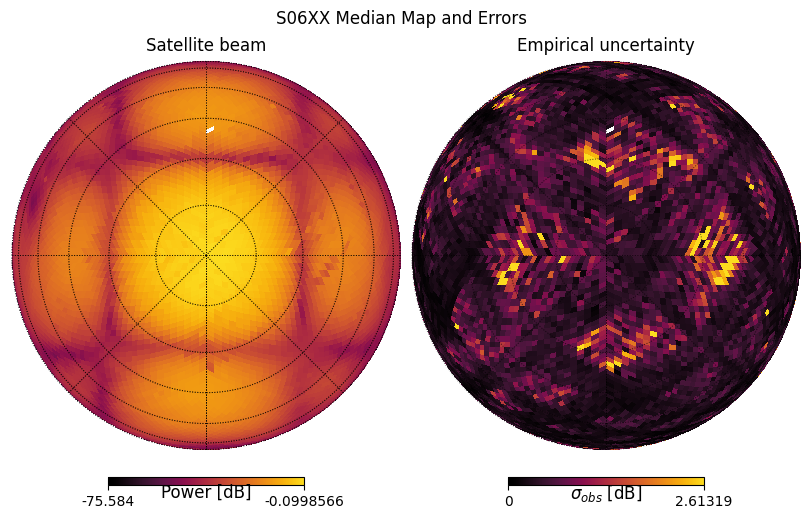

In [6]:
def plot_healpix_map(
    healpix_map,
    *,
    fig,
    sub,
    title="",
    unit="",
    vmin=None,
    vmax=None,
    cmap=None,
    badcolor="whitesmoke",
):
    hp.orthview(
        map=np.asarray(healpix_map),
        fig=fig,
        sub=sub,
        rot=(0, 90, 180),
        half_sky=True,
        min=vmin,
        max=vmax,
        title=title,
        unit=unit,
        badcolor=badcolor,
        cmap=cmap,
        notext=True,
    )

    hp.graticule(
        dpar=15,
        dmer=45,
        ls=":",
        lw=0.7,
        alpha=0.7,
    )


fig = plt.figure(figsize=(8, 5.3))

plot_healpix_map(
    data_map,
    fig=fig,
    sub=(1, 2, 1),
    title="Satellite beam",
    unit="Power [dB]",
    cmap=wfr_lin,
)

plot_healpix_map(
    error_map,
    fig=fig,
    sub=(1, 2, 2),
    title="Empirical uncertainty",
    unit=r"$\sigma_{obs}$ [dB]",
    vmin=0,
    vmax=np.nanpercentile(error_map, 99),
    cmap=wfr_lin,
)

fig.suptitle(f"{tilepol} Median Map and Errors")
plt.show()

## 3. Reconstruct the AEE forward model

The refactored AEE model separates two different operations:

$$
\text{dipole flags}
\rightarrow
\text{coupled current solve}
\rightarrow
\text{complex dipole gains}
\rightarrow
\text{array factor}.
$$

The nominal coupled currents are calculated from

$$
\mathbf I
=
\mathbf Z^{-1}\mathbf V,
$$

where the unflagged driven ports have unit voltage and flagged ports have zero
voltage.

The inferred complex gains are **not** used in this solve. They are applied afterward
to the complete coupled response associated with each driven dipole/feed.

For an XX fit we infer the 16 X-feed gains while keeping all Y-feed gains equal to
unity. For a YY fit the roles are reversed.

In [7]:
visible_indices = np.flatnonzero(sampled_visible)

visible_lookup = np.full(
    N_PIXELS,
    -1,
    dtype=np.int32,
)
visible_lookup[visible_indices] = np.arange(
    visible_indices.size,
    dtype=np.int32,
)

comparison_visible_indices = visible_lookup[comparison_indices]

if np.any(comparison_visible_indices < 0):
    raise ValueError(
        "At least one comparison pixel lies outside the sampled visible set."
    )

az_visible = jnp.asarray(
    az_hpx[sampled_visible],
    dtype=jnp.float32,
)
za_visible = jnp.asarray(
    za_hpx[sampled_visible],
    dtype=jnp.float32,
)
comparison_visible_indices_jax = jnp.asarray(
    comparison_visible_indices,
    dtype=jnp.int32,
)


@jax.jit
def predict_beam_db(dipole_gains_pol):
    fixed = jnp.ones(
        N_DIPOLES,
        dtype=jnp.complex64,
    )

    dipole_gains_pol = dipole_gains_pol.astype(
        jnp.complex64
    )

    dipole_gains = (
        jnp.stack([dipole_gains_pol, fixed])
        if POL == 0
        else jnp.stack([fixed, dipole_gains_pol])
    )

    power = aee.power(
        az_rad=az_visible,
        za_rad=za_visible,
        dipole_gains=dipole_gains,
        normalize=True,
    )[POL, comparison_visible_indices_jax]

    power = jnp.maximum(
        power,
        jnp.finfo(power.dtype).tiny,
    )

    return 10 * jnp.log10(power)


nominal_gains = jnp.ones(
    N_DIPOLES,
    dtype=jnp.complex64,
)

nominal_model_db = np.asarray(
    predict_beam_db(nominal_gains),
    dtype=float,
)

nominal_residual_db = observed_db - nominal_model_db

print("Forward-model output:", nominal_model_db.shape)
print(
    "Nominal residual RMS:",
    f"{np.sqrt(np.mean(nominal_residual_db**2)):.3f} dB",
)

Forward-model output: (6072,)
Nominal residual RMS: 7.889 dB


## 4. Effective dipole coefficients

For one fitted polarization, each physical dipole contributes two nominal complex
AEE current terms to the corresponding array factor:

- $I_n^{\rm dir}$: the current contribution from driving the fitted feed;
- $I_n^{\rm cross}$: the contribution on the same port polarization generated by
  driving the other feed through mutual coupling.

For example, in an XX fit,

$$
I_n^{\rm dir}=I_{X\leftarrow X,n},
\qquad
I_n^{\rm cross}=I_{X\leftarrow Y,n}.
$$

The inferred gain $g_n$ multiplies the directly driven response, while the gain of
the other feed is fixed to unity. The total complex coefficient contributed by
dipole $n$ is therefore

$$
c_n(g)
=
g_n I_n^{\rm dir}
+
I_n^{\rm cross}.
$$

This $c_n$, rather than $g_n$ alone, is the complex coefficient that enters the
coherent array sum.

In [8]:
currents = jnp.asarray(aee.port_currents())

# currents has shape:
#     (port polarization, driven feed, dipole)
if POL == 0:
    i_direct = currents[0, 0]
    i_cross = currents[0, 1]
elif POL == 1:
    i_direct = currents[1, 1]
    i_cross = currents[1, 0]
else:
    raise ValueError(f"Unexpected POL={POL}")


@jax.jit
def effective_coefficients(dipole_gains_pol):
    """Return c_n = g_n I_direct,n + I_cross,n."""
    return (
        dipole_gains_pol.astype(jnp.complex64) * i_direct
        + i_cross
    )


nominal_coefficients = effective_coefficients(nominal_gains)

print("Nominal coefficient shape:", nominal_coefficients.shape)
print("Direct-current dtype:", i_direct.dtype)
print("Cross-current dtype:", i_cross.dtype)

Nominal coefficient shape: (16,)
Direct-current dtype: complex64
Cross-current dtype: complex64


## 5. Symmetry statistic

We retain the effective-coefficient construction from the previous analysis,

$$
c_n(g)=g_n I_n^{\rm dir}+I_n^{\rm cross},
$$

and use

$$
S(g)
=
\sum_{n=0}^{7}
\left(
|c_n|^2-|c_{15-n}|^2
\right)
$$

only as a **diagnostic label** for the two conjugate branches. NSS itself is not
restricted to either sign of $S(g)$.

Under the ideal conjugate-rotation transformation,

$$
S(Tg)=-S(g).
$$

In [9]:
PAIR_LEFT = jnp.arange(8)
PAIR_RIGHT = 15 - PAIR_LEFT


@jax.jit
def symmetry_statistic(dipole_gains_pol):
    """Return S(g) for one 16-element complex gain vector."""
    coefficients = effective_coefficients(dipole_gains_pol)

    return jnp.sum(
        jnp.abs(coefficients[PAIR_LEFT]) ** 2
        - jnp.abs(coefficients[PAIR_RIGHT]) ** 2
    )


nominal_s = float(symmetry_statistic(nominal_gains))

print(f"S(g=1): {nominal_s:.6e}")
print(
    "Nominal branch:",
    "positive" if nominal_s > 0 else "negative" if nominal_s < 0 else "boundary",
)

S(g=1): -1.194463e-11
Nominal branch: negative


# Part I — Nested-sampling parameterization

## 6. A normalized prior in 30 independent coordinates

BlackJAX NSS works with a Euclidean particle position and requires separate
`logprior_fn` and `loglikelihood_fn` functions.

The physical model has 30 independent parameters:

- 15 independent amplitude degrees of freedom, because the 16 gain amplitudes are
  constrained to sum to 16;
- 15 relative phases, because dipole 0 is the phase reference.

For the amplitudes we use the same additive-log-ratio coordinates used in the
Laplace work,

$$
z_i = \log\frac{f_i}{f_{15}},
\qquad i=0,\ldots,14,
$$

where $f_n=a_n/16$ and $\sum_n f_n=1$. The inverse map is a softmax with the
last logit fixed to zero.

The original Dirichlet prior is defined on the simplex, so its density in the
log-ratio coordinates includes the inverse-transform Jacobian,

$$
\log|J|=\sum_{n=0}^{15}\log f_n.
$$

The remaining 15 coordinates are the physical relative phases
$\phi_1,\ldots,\phi_{15}$. They are restricted to $[-\pi,\pi)$ and retain the
same Von Mises prior used by the SMC analysis.

This is important for nested sampling: the prior supplied to NSS must be a properly
normalized probability density in the coordinates in which the live points move.


In [10]:
import importlib.metadata

import blackjax
import numpyro.distributions as dist
from blackjax.ns.utils import finalise, log_weights, ess
from blackjax.ns.utils import sample as ns_sample
from jax.scipy.special import logsumexp

BLACKJAX_VERSION = importlib.metadata.version("blackjax")
print("BlackJAX version:", BLACKJAX_VERSION)

if not hasattr(blackjax, "nss"):
    raise RuntimeError(
        "This notebook requires a BlackJAX release exposing `blackjax.nss`. "
        "The current Sampling Book examples use the BlackJAX 1.6.x API."
    )

N_AMPLITUDE_COORDS = N_DIPOLES - 1
N_PHASE_COORDS = N_DIPOLES - 1
LATENT_DIM = N_AMPLITUDE_COORDS + N_PHASE_COORDS

print("Latent dimension:", LATENT_DIM)


BlackJAX version: 1.6.2
Latent dimension: 30


In [11]:
# -------------------------------------------------------------------------
# Coordinate transforms.
# -------------------------------------------------------------------------

def fractions_to_logratios(fraction):
    """Map 16 simplex fractions to 15 additive log-ratio coordinates."""
    fraction = jnp.asarray(fraction)
    return jnp.log(
        fraction[..., :-1]
        / fraction[..., -1:]
    )


def position_to_physical(position):
    """Return simplex fractions, relative phases, and complex gains."""
    position = jnp.asarray(position)

    amp_coordinates = position[..., :N_AMPLITUDE_COORDS]
    relative_phase = position[..., N_AMPLITUDE_COORDS:]

    logits = jnp.concatenate(
        [
            amp_coordinates,
            jnp.zeros(
                amp_coordinates.shape[:-1] + (1,),
                dtype=position.dtype,
            ),
        ],
        axis=-1,
    )

    fraction = jax.nn.softmax(
        logits,
        axis=-1,
    )

    amplitude = N_DIPOLES * fraction

    phase = jnp.concatenate(
        [
            jnp.zeros(
                relative_phase.shape[:-1] + (1,),
                dtype=position.dtype,
            ),
            relative_phase,
        ],
        axis=-1,
    )

    gains = (
        amplitude
        * jnp.exp(1j * phase)
    ).astype(jnp.complex64)

    return fraction, relative_phase, gains


In [12]:
# -------------------------------------------------------------------------
# Prior density in the nested-sampling coordinates.
# -------------------------------------------------------------------------

DIRICHLET_CONCENTRATION = jnp.full(
    N_DIPOLES,
    DIRICHLET_ALPHA,
    dtype=jnp.float32,
)

PHASE_LOG_I0 = (
    jnp.log(
        jax.scipy.special.i0e(
            jnp.asarray(
                PHASE_KAPPA,
                dtype=jnp.float32,
            )
        )
    )
    + jnp.asarray(
        PHASE_KAPPA,
        dtype=jnp.float32,
    )
)


@jax.jit
def logprior_fn(position):
    fraction, relative_phase, _ = position_to_physical(
        position
    )

    # Dirichlet density on the physical simplex.
    logprior_amplitude = (
        jax.scipy.special.gammaln(
            jnp.sum(
                DIRICHLET_CONCENTRATION
            )
        )
        - jnp.sum(
            jax.scipy.special.gammaln(
                DIRICHLET_CONCENTRATION
            )
        )
        + jnp.sum(
            (DIRICHLET_CONCENTRATION - 1.0)
            * jnp.log(fraction)
        )
    )

    # Change-of-variables factor for simplex fractions -> ALR coordinates.
    log_abs_det_jacobian = jnp.sum(
        jnp.log(fraction)
    )

    # Physical relative phases live on one fundamental interval.
    phase_in_bounds = jnp.all(
        (relative_phase >= -jnp.pi)
        & (relative_phase < jnp.pi)
    )

    logprior_phase = jnp.sum(
        PHASE_KAPPA * jnp.cos(relative_phase)
        - jnp.log(2.0 * jnp.pi)
        - PHASE_LOG_I0
    )

    logprior = (
        logprior_amplitude
        + log_abs_det_jacobian
        + logprior_phase
    )

    return jnp.where(
        phase_in_bounds,
        logprior,
        -jnp.inf,
    )


In [13]:
# -------------------------------------------------------------------------
# Likelihood. This is the same Normal-in-dB likelihood used by the SMC model.
# -------------------------------------------------------------------------

observed_db_jax = jnp.asarray(
    observed_db,
    dtype=jnp.float32,
)
observed_sigma_db_jax = jnp.asarray(
    observed_sigma_db,
    dtype=jnp.float32,
)


@jax.jit
def loglikelihood_fn(position):
    _, _, gains = position_to_physical(
        position
    )

    model_db = predict_beam_db(
        gains
    )

    return jnp.sum(
        -0.5
        * (
            (observed_db_jax - model_db)
            / observed_sigma_db_jax
        ) ** 2
        - jnp.log(
            observed_sigma_db_jax
        )
        - 0.5 * jnp.log(
            2.0 * jnp.pi
        )
    )


## 7. Draw the live set directly from the physical prior

Nested sampling begins with live points drawn from the prior itself. We therefore:

1. draw fractions from the same Dirichlet prior used in the SMC run;
2. draw the 15 relative phases from the same Von Mises prior;
3. convert only the fractions to the 15 log-ratio coordinates used by NSS.

This gives exact prior draws in the 30-dimensional coordinates used by
`logprior_fn`.


In [14]:
def sample_prior_positions(rng_key, num_samples):
    """Draw independent NSS positions from the physical model prior."""
    amplitude_key, phase_key = jax.random.split(
        rng_key
    )

    fraction = dist.Dirichlet(
        DIRICHLET_CONCENTRATION
    ).sample(
        amplitude_key,
        sample_shape=(num_samples,),
    )

    relative_phase = (
        dist.VonMises(
            loc=jnp.zeros(
                N_PHASE_COORDS,
                dtype=jnp.float32,
            ),
            concentration=jnp.full(
                N_PHASE_COORDS,
                PHASE_KAPPA,
                dtype=jnp.float32,
            ),
        )
        .to_event(1)
        .sample(
            phase_key,
            sample_shape=(num_samples,),
        )
    )

    amp_coordinates = fractions_to_logratios(
        fraction
    )

    return jnp.concatenate(
        [
            amp_coordinates,
            relative_phase,
        ],
        axis=-1,
    ).astype(jnp.float32)


In [15]:
# Small prior sanity check before launching an expensive run.

prior_check_key = jax.random.key(123)
prior_check = sample_prior_positions(
    prior_check_key,
    1024,
)

prior_fraction, prior_phase, prior_gains = jax.vmap(
    position_to_physical
)(prior_check)

prior_logp = jax.vmap(
    logprior_fn
)(prior_check)

print("Prior positions:", prior_check.shape)
print(
    "Finite log-prior:",
    f"{np.mean(np.isfinite(np.asarray(prior_logp))):.3%}",
)
print(
    "Mean amplitude sum:",
    float(
        np.mean(
            np.asarray(
                jnp.abs(prior_gains).sum(axis=1)
            )
        )
    ),
)
print(
    "Mean dipole amplitude:",
    float(
        np.mean(
            np.asarray(
                jnp.abs(prior_gains)
            )
        )
    ),
)
print(
    "Max |relative phase| [deg]:",
    float(
        np.max(
            np.abs(
                np.rad2deg(
                    np.asarray(prior_phase)
                )
            )
        )
    ),
)


Prior positions: (1024, 30)
Finite log-prior: 100.000%
Mean amplitude sum: 16.0
Mean dipole amplitude: 1.0
Max |relative phase| [deg]: 39.297122955322266


# Part II — BlackJAX Nested Slice Sampling

## 8. Initial exploration configuration

The current BlackJAX Sampling Book identifies three NSS settings worth varying:

- `num_live`: number of live points retained throughout the run;
- `num_delete`: number of lowest-likelihood points replaced at each outer step;
- `num_inner_steps`: constrained hit-and-run slice moves used to generate each
  replacement point.

The Sampling Book suggests an inner-step scale of order

$$
\max(5,2d),
$$

which is $60$ for this $d=30$ problem.

The settings below are deliberately a **first exploration**, not final production
choices. A useful first robustness study will compare multiple `num_live`,
`num_inner_steps`, and stopping thresholds.

The stopping statistic is

$$
\log Z_{\rm live}-\log Z.
$$

The standard general-purpose criterion used in the Sampling Book is `-3`. If this
beam posterior exhibits a sharp phase-transition-like compression, we should test
deeper stopping values such as `-5` or `-10` rather than assuming `-3` is sufficient.


In [16]:
# -------------------------------------------------------------------------
# NSS configuration.
# -------------------------------------------------------------------------
NUM_LIVE = 512
NUM_DELETE = 32
NUM_INNER_STEPS = 5
DLOGZ = -3.0
MAX_NS_STEPS = 50_000
REPORT_EVERY = 10

N_LOGZ_DRAWS = 300
N_POSTERIOR_SAMPLES = 4_000

NSS_SEED = 42

print("Nested-sampling configuration")
print("-----------------------------")
print(f"num_live:          {NUM_LIVE}")
print(f"num_delete:        {NUM_DELETE}")
print(
    "delete fraction:    "
    f"{NUM_DELETE / NUM_LIVE:.3%}"
)
print(f"num_inner_steps:   {NUM_INNER_STEPS}")
print(f"latent dimension:  {LATENT_DIM}")
print(f"dlogZ stop:        {DLOGZ}")


Nested-sampling configuration
-----------------------------
num_live:          512
num_delete:        32
delete fraction:    6.250%
num_inner_steps:   5
latent dimension:  30
dlogZ stop:        -3.0


In [17]:
# -------------------------------------------------------------------------
# Build the BlackJAX Nested Slice Sampler.
# -------------------------------------------------------------------------

nss = blackjax.nss(
    logprior_fn=logprior_fn,
    loglikelihood_fn=loglikelihood_fn,
    num_inner_steps=NUM_INNER_STEPS,
    num_delete=NUM_DELETE,
)

nss_step = jax.jit(
    nss.step
)


In [18]:
def run_nested_sampling(
    rng_key,
    algorithm,
    initial_particles,
    *,
    dlogz=DLOGZ,
    max_steps=MAX_NS_STEPS,
    report_every=REPORT_EVERY,
):
    """Run NSS until the estimated live evidence is negligible."""
    state = algorithm.init(
        initial_particles
    )

    dead = []

    for step_index in range(
        1,
        max_steps + 1,
    ):
        rng_key, step_key = jax.random.split(
            rng_key
        )

        state, info = nss_step(
            step_key,
            state,
        )

        dead.append(info)

        remaining = float(
            state.integrator.logZ_live
            - state.integrator.logZ
        )

        if (
            step_index == 1
            or step_index % report_every == 0
        ):
            live_logl = np.asarray(
                state.particles.loglikelihood
            )

            print(
                f"step={step_index:6d}  "
                f"logL_min={live_logl.min():12.2f}  "
                f"logL_med={np.median(live_logl):12.2f}  "
                f"logL_max={live_logl.max():12.2f}  "
                f"dlogZ_live={remaining:8.3f}"
            )

        if remaining < dlogz:
            print(
                f"Stopping after {step_index} steps: "
                f"logZ_live - logZ = {remaining:.3f} < {dlogz:.3f}"
            )
            break
    else:
        raise RuntimeError(
            "Nested sampling reached MAX_NS_STEPS before satisfying "
            "the dlogZ stopping criterion."
        )

    return finalise(
        state,
        dead,
    )


## 9. Run NSS

The cell below performs the expensive calculation. The first execution includes JAX
compilation overhead.

For the first S06XX benchmark, record the wall time as well as the number of dead
points. These are the quantities we will eventually compare with the existing
SMC+NUTS run.


In [19]:
rng_key = jax.random.key(
    NSS_SEED
)

rng_key, init_key, run_key = jax.random.split(
    rng_key,
    3,
)

initial_live = sample_prior_positions(
    init_key,
    NUM_LIVE,
)

print(
    "Initial live-set log-likelihood range:",
    float(
        jax.vmap(loglikelihood_fn)(
            initial_live
        ).min()
    ),
    "to",
    float(
        jax.vmap(loglikelihood_fn)(
            initial_live
        ).max()
    ),
)

# Run the sampler.
ns_run = run_nested_sampling(
    run_key,
    nss,
    initial_live,
)

print(
    "Finalised points:",
    ns_run.particles.loglikelihood.shape[0],
)


Initial live-set log-likelihood range: -2840030.0 to -592060.25
step=     1  logL_min= -1878283.25  logL_med= -1322412.12  logL_max=  -592060.25  dlogZ_live=1287823.500
step=    10  logL_min= -1375508.88  logL_med= -1137261.75  logL_max=  -592060.25  dlogZ_live=783652.000
step=    20  logL_min= -1144900.38  logL_med= -1004173.94  logL_max=  -592060.25  dlogZ_live=553381.312
step=    30  logL_min= -1014425.56  logL_med=  -932101.62  logL_max=  -586849.12  dlogZ_live=427641.000
step=    40  logL_min=  -934188.25  logL_med=  -856402.56  logL_max=  -469772.38  dlogZ_live=465717.656
step=    50  logL_min=  -861166.00  logL_med=  -798296.00  logL_max=  -469772.38  dlogZ_live=391867.969
step=    60  logL_min=  -799674.75  logL_med=  -734358.25  logL_max=  -459912.88  dlogZ_live=340144.312
step=    70  logL_min=  -741140.06  logL_med=  -684127.12  logL_max=  -417491.25  dlogZ_live=323688.500
step=    80  logL_min=  -690054.50  logL_med=  -640089.75  logL_max=  -417491.25  dlogZ_live=273115.094

# Part III — Evidence and posterior reconstruction

## 10. Evidence

Nested sampling assigns each discarded point an importance weight approximately
proportional to

$$
\mathcal L_i\,\mathrm dX_i,
$$

where $\mathrm dX_i$ is the prior-volume shell represented by that point.

The prior-volume sequence is stochastic. BlackJAX therefore generates multiple
realizations of the nested volumes, giving a distribution of $\log Z$ rather than
a single deterministic estimate.


In [20]:
rng_key, weights_key, ess_key = jax.random.split(
    rng_key,
    3,
)

ns_log_weights = log_weights(
    weights_key,
    ns_run,
    shape=N_LOGZ_DRAWS,
)

ns_logz = logsumexp(
    ns_log_weights,
    axis=0,
)

ns_ess = ess(
    ess_key,
    ns_run,
)

print("Nested-sampling evidence")
print("------------------------")
print(
    "log Z:",
    f"{float(ns_logz.mean()):.3f} "
    f"+/- {float(ns_logz.std()):.3f}",
)
print(
    "posterior ESS:",
    f"{float(ns_ess):.0f}",
)
print(
    "dead + final live points:",
    ns_run.particles.loglikelihood.shape[0],
)


Nested-sampling evidence
------------------------
log Z: -146799.438 +/- 0.546
posterior ESS: 6117
dead + final live points: 75168


## 11. Equally weighted posterior samples

The live set itself is **not** the posterior. The posterior is reconstructed from
the full nested-sampling history using the evidence weights.

`ns_sample` draws an equally weighted posterior sample from those weighted nested
points.


In [21]:
rng_key, posterior_key = jax.random.split(
    rng_key
)

posterior_state = ns_sample(
    posterior_key,
    ns_run,
    N_POSTERIOR_SAMPLES,
)

posterior_position = jnp.asarray(
    posterior_state.position
)

posterior_fraction, posterior_phase, posterior_gains = jax.vmap(
    position_to_physical
)(
    posterior_position
)

posterior_amplitude = np.asarray(
    jnp.abs(posterior_gains)
)

posterior_phase_full_rad = np.asarray(
    jnp.concatenate(
        [
            jnp.zeros(
                (
                    posterior_phase.shape[0],
                    1,
                ),
                dtype=posterior_phase.dtype,
            ),
            posterior_phase,
        ],
        axis=1,
    )
)

posterior_gains_np = np.asarray(
    posterior_gains
)

print("Posterior samples:", posterior_position.shape)
print(
    "Amplitude-sum range:",
    posterior_amplitude.sum(axis=1).min(),
    "to",
    posterior_amplitude.sum(axis=1).max(),
)


Posterior samples: (4000, 30)
Amplitude-sum range: 15.999997 to 16.000004


# Part IV — Conjugate-mode diagnostics

## 12. Evaluate \(S(g)\) for the nested posterior

The sign of \(S(g)\) gives us a deterministic label for the two
conjugate-rotation branches without introducing a clustering model.


In [22]:
posterior_s = np.asarray(
    jax.vmap(
        symmetry_statistic
    )(
        posterior_gains
    )
)

positive = posterior_s > 0.0
negative = posterior_s < 0.0

print("Posterior branch occupancy")
print("--------------------------")
print(
    f"S > 0: {positive.sum():5d} "
    f"({positive.mean():7.3%})"
)
print(
    f"S < 0: {negative.sum():5d} "
    f"({negative.mean():7.3%})"
)
print(
    "S range:",
    f"{posterior_s.min():+.6e}",
    "to",
    f"{posterior_s.max():+.6e}",
)


Posterior branch occupancy
--------------------------
S > 0:     0 ( 0.000%)
S < 0:  4000 (100.000%)
S range: -1.180708e-06 to -1.101257e-06


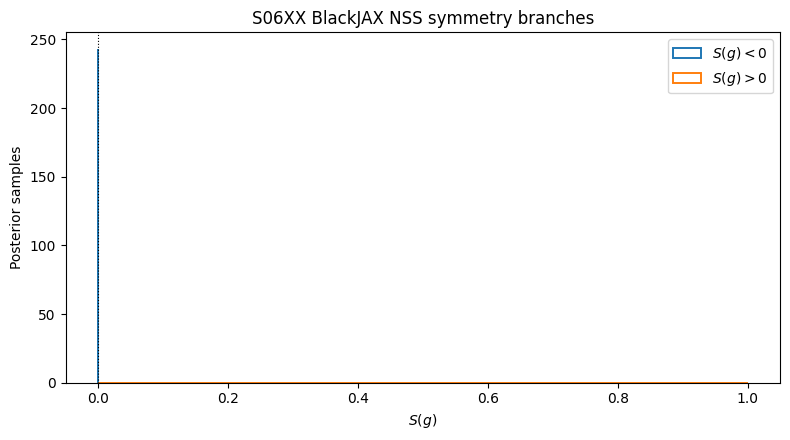

In [23]:
fig, ax = plt.subplots(
    figsize=(8, 4.5)
)

ax.hist(
    posterior_s[negative],
    bins=50,
    histtype="step",
    linewidth=1.4,
    label=r"$S(g)<0$",
)

ax.hist(
    posterior_s[positive],
    bins=50,
    histtype="step",
    linewidth=1.4,
    label=r"$S(g)>0$",
)

ax.axvline(
    0.0,
    color="black",
    ls=":",
    lw=0.8,
)

ax.set_xlabel(r"$S(g)$")
ax.set_ylabel("Posterior samples")
ax.set_title(
    f"{tilepol} BlackJAX NSS symmetry branches"
)
ax.legend()

fig.tight_layout()
plt.show()


## 13. Branch masses directly from nested-sampling weights

The equally weighted posterior occupancy above is a Monte Carlo draw from the
nested posterior. We can also estimate the branch mass directly from the nested
importance weights.

For each stochastic prior-volume realization we compute

$$
P(S>0\mid D)
=
\frac{\sum_{i:S_i>0} w_i}
{\sum_i w_i},
$$

and similarly for $S<0$. The variation across the volume realizations provides a
nested-sampling uncertainty estimate on the branch mass itself.

This is one of the key diagnostics for comparison with the existing SMC particle
occupancy and the Gaussian Laplace estimate.


In [24]:
all_position = jnp.asarray(
    ns_run.particles.position
)

_, _, all_gains = jax.vmap(
    position_to_physical
)(
    all_position
)

all_s = np.asarray(
    jax.vmap(
        symmetry_statistic
    )(
        all_gains
    )
)

all_positive = jnp.asarray(
    all_s > 0.0
)
all_negative = jnp.asarray(
    all_s < 0.0
)

minus_inf = jnp.asarray(
    -jnp.inf,
    dtype=ns_log_weights.dtype,
)

logz_total_draws = logsumexp(
    ns_log_weights,
    axis=0,
)

logz_positive_draws = logsumexp(
    jnp.where(
        all_positive[:, None],
        ns_log_weights,
        minus_inf,
    ),
    axis=0,
)

logz_negative_draws = logsumexp(
    jnp.where(
        all_negative[:, None],
        ns_log_weights,
        minus_inf,
    ),
    axis=0,
)

positive_mass_draws = jnp.exp(
    logz_positive_draws
    - logz_total_draws
)

negative_mass_draws = jnp.exp(
    logz_negative_draws
    - logz_total_draws
)

print("Nested branch-mass estimate")
print("---------------------------")
print(
    "S > 0:",
    f"{float(positive_mass_draws.mean()):.3%} "
    f"+/- {float(positive_mass_draws.std()):.3%}",
)
print(
    "S < 0:",
    f"{float(negative_mass_draws.mean()):.3%} "
    f"+/- {float(negative_mass_draws.std()):.3%}",
)

log_mass_ratio_draws = (
    logz_positive_draws
    - logz_negative_draws
)

print(
    "Delta log branch mass (positive - negative):",
    f"{float(log_mass_ratio_draws.mean()):+.3f} "
    f"+/- {float(log_mass_ratio_draws.std()):.3f}",
)


Nested branch-mass estimate
---------------------------
S > 0: 0.000% +/- 0.000%
S < 0: 100.000% +/- 0.000%
Delta log branch mass (positive - negative): -3631.825 +/- 0.878


## 14. Physical projection of the two modes

A simple conjugate-dipole projection is useful for checking whether NSS has recovered
the same two local structures seen by SMC.

The pair $1\leftrightarrow14$ is used for both amplitude and phase so that the two
panels show the same physical dipoles.


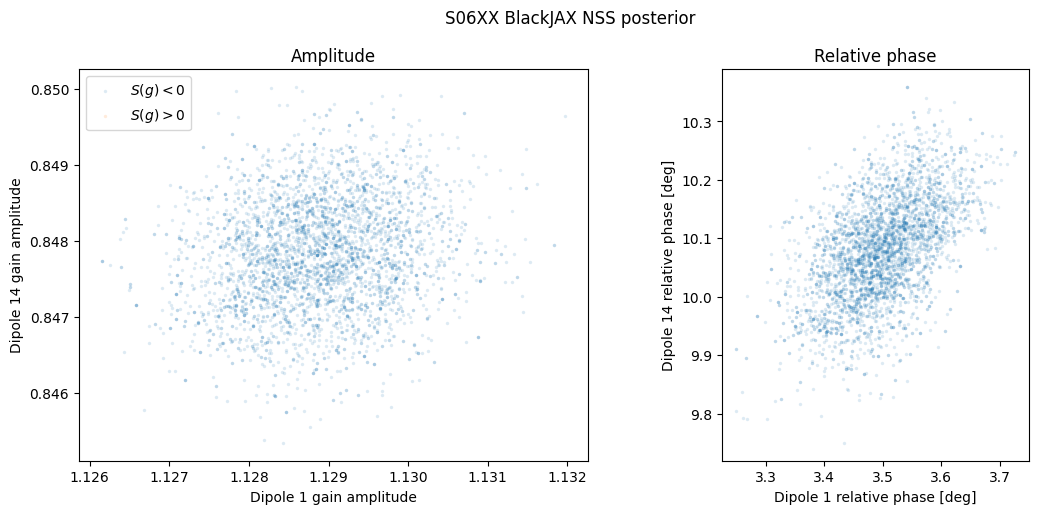

In [25]:
PAIR_A = 1
PAIR_B = 14

fig, (ax_amp, ax_phase) = plt.subplots(
    1,
    2,
    figsize=(11.5, 5.2),
)

for mask, label in (
    (negative, r"$S(g)<0$"),
    (positive, r"$S(g)>0$"),
):
    ax_amp.scatter(
        posterior_amplitude[
            mask,
            PAIR_A,
        ],
        posterior_amplitude[
            mask,
            PAIR_B,
        ],
        s=6,
        alpha=0.15,
        linewidths=0,
        rasterized=True,
        label=label,
    )

    ax_phase.scatter(
        np.rad2deg(
            posterior_phase_full_rad[
                mask,
                PAIR_A,
            ]
        ),
        np.rad2deg(
            posterior_phase_full_rad[
                mask,
                PAIR_B,
            ]
        ),
        s=6,
        alpha=0.15,
        linewidths=0,
        rasterized=True,
    )

# ax_amp.axvline(
#     1.0,
#     color="black",
#     ls=":",
#     lw=0.8,
# )
# ax_amp.axhline(
#     1.0,
#     color="black",
#     ls=":",
#     lw=0.8,
# )

# amp_limits = ax_amp.get_xlim()
# ax_amp.plot(
#     amp_limits,
#     amp_limits,
#     color="black",
#     ls="--",
#     lw=0.8,
#     alpha=0.6,
# )
# ax_amp.set_xlim(amp_limits)
# ax_amp.set_ylim(amp_limits)
# ax_amp.set_aspect("equal")

ax_amp.set_xlabel(
    f"Dipole {PAIR_A} gain amplitude"
)
ax_amp.set_ylabel(
    f"Dipole {PAIR_B} gain amplitude"
)
ax_amp.set_title("Amplitude")
ax_amp.legend()

ax_phase.set_xlabel(
    f"Dipole {PAIR_A} relative phase [deg]"
)
ax_phase.set_ylabel(
    f"Dipole {PAIR_B} relative phase [deg]"
)
ax_phase.set_title("Relative phase")
ax_phase.set_aspect("equal")

fig.suptitle(
    f"{tilepol} BlackJAX NSS posterior"
)

fig.tight_layout()
plt.show()


# Part V — Diagnostics and next experiments

## 15. Compression history

Nested sampling's defining diagnostic is the progression through likelihood
contours. Sorting the finalized points by likelihood allows us to reconstruct a
simple view of the live-set mean likelihood as the prior volume contracts.

A plateau followed by renewed compression would be especially interesting in light
of the phase-transition example that motivated this experiment.


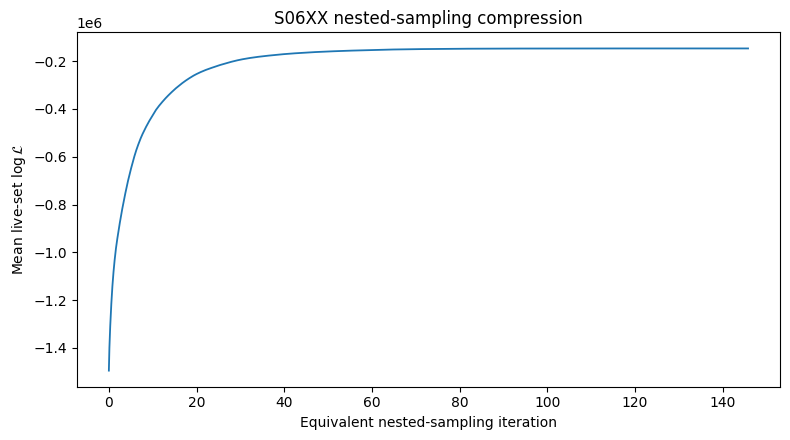

In [26]:
sorted_logl = np.sort(
    np.asarray(
        ns_run.particles.loglikelihood
    )
)

num_points = sorted_logl.size
num_outer_steps = max(
    0,
    (num_points - NUM_LIVE)
    // NUM_DELETE,
)

starts = (
    np.arange(num_outer_steps)
    * NUM_DELETE
)

mean_live_logl = np.asarray(
    [
        sorted_logl[
            start : start + NUM_LIVE
        ].mean()
        for start in starts
    ]
)

equivalent_iterations = (
    starts / NUM_LIVE
)

fig, ax = plt.subplots(
    figsize=(8, 4.5)
)

ax.plot(
    equivalent_iterations,
    mean_live_logl,
    lw=1.3,
)

ax.set_xlabel(
    "Equivalent nested-sampling iteration"
)
ax.set_ylabel(
    r"Mean live-set $\log \mathcal{L}$"
)
ax.set_title(
    f"{tilepol} nested-sampling compression"
)

fig.tight_layout()
plt.show()


In [27]:
refined_modes = np.load(
    "S06XX_refined_modes.npz"
)

refined_gains = {
    "source": refined_modes["source"],
    "partner": refined_modes["partner"],
}

for name, gains in refined_gains.items():
    print(
        f"{name:8s}: "
        f"shape={gains.shape}, "
        f"dtype={gains.dtype}, "
        f"sum|g|={np.abs(gains).sum():.8f}"
    )

source  : shape=(16,), dtype=complex64, sum|g|=16.00000000
partner : shape=(16,), dtype=complex64, sum|g|=16.00000000


In [28]:
# -------------------------------------------------------------------------
# Diagnostic: compare the NSS target at the known symmetry-related MAPs
# against the best point found by nested sampling.
#
# Everything below is evaluated using the NSS notebook's own
# loglikelihood_fn / logprior_fn / coordinate parameterization.
# -------------------------------------------------------------------------


def gains_to_nss_position(gains):
    """Convert physical complex gains to the 30-D NSS coordinate vector."""
    gains = np.asarray(
        gains,
        dtype=np.complex128,
    )

    amplitude = np.abs(gains)

    # Enforce the same amplitude normalization used by the model.
    fraction = (
        amplitude
        / amplitude.sum()
    )

    amp_coordinates = np.log(
        fraction[:-1]
        / fraction[-1]
    )

    # Dipole 0 defines the phase reference.
    relative_phase = np.angle(
        gains[1:]
        / gains[0]
    )

    return jnp.asarray(
        np.concatenate(
            [
                amp_coordinates,
                relative_phase,
            ]
        ),
        dtype=jnp.float32,
    )


def evaluate_nss_target(position):
    """Return NSS log likelihood, log prior, and log posterior."""
    log_likelihood = float(
        loglikelihood_fn(
            position
        )
    )

    log_prior = float(
        logprior_fn(
            position
        )
    )

    return {
        "log_likelihood": log_likelihood,
        "log_prior": log_prior,
        "log_posterior": (
            log_likelihood
            + log_prior
        ),
    }


# -------------------------------------------------------------------------
# Known source / partner MAPs from the Laplace analysis.
# -------------------------------------------------------------------------

source_map_position = gains_to_nss_position(
    refined_gains["source"]
)

partner_map_position = gains_to_nss_position(
    refined_gains["partner"]
)


# -------------------------------------------------------------------------
# Best likelihood point found anywhere in the finalized NSS run.
# -------------------------------------------------------------------------

all_logl = np.asarray(
    ns_run.particles.loglikelihood
)

best_nss_index = int(
    np.argmax(
        all_logl
    )
)

best_nss_position = jnp.asarray(
    ns_run.particles.position[
        best_nss_index
    ]
)


# -------------------------------------------------------------------------
# Evaluate all three using exactly the same NSS target.
# -------------------------------------------------------------------------

diagnostic_results = {
    "Laplace source MAP": evaluate_nss_target(
        source_map_position
    ),
    "Laplace partner MAP": evaluate_nss_target(
        partner_map_position
    ),
    "Best NSS point": evaluate_nss_target(
        best_nss_position
    ),
}


print("NSS target consistency check")
print("----------------------------")

for name, values in diagnostic_results.items():
    print(
        f"{name:20s}: "
        f"logL={values['log_likelihood']:12.3f}, "
        f"logPrior={values['log_prior']:9.3f}, "
        f"logPost={values['log_posterior']:12.3f}"
    )


# -------------------------------------------------------------------------
# Physical diagnostics for the same points.
# -------------------------------------------------------------------------

print()
print("Physical locations")
print("------------------")

for name, position in (
    ("Laplace source MAP", source_map_position),
    ("Laplace partner MAP", partner_map_position),
    ("Best NSS point", best_nss_position),
):
    fraction, relative_phase, gains = position_to_physical(
        position
    )

    gains = np.asarray(
        gains
    )

    print(name)
    print(
        "  amplitude sum:",
        f"{np.abs(gains).sum():.8f}",
    )
    print(
        "  S(g):",
        f"{float(symmetry_statistic(gains)):+.6e}",
    )
    print(
        "  phi_1 [deg]:",
        f"{np.rad2deg(np.angle(gains[1])):+.4f}",
    )
    print(
        "  phi_14 [deg]:",
        f"{np.rad2deg(np.angle(gains[14])):+.4f}",
    )
    print()

NSS target consistency check
----------------------------
Laplace source MAP  : logL= -146531.375, logPrior=   10.727, logPost= -146520.648
Laplace partner MAP : logL= -146531.391, logPrior=    9.867, logPost= -146521.523
Best NSS point      : logL= -146649.375, logPrior=    8.510, logPost= -146640.865

Physical locations
------------------
Laplace source MAP
  amplitude sum: 16.00000000
  S(g): +6.873777e-07
  phi_1 [deg]: -0.9519
  phi_14 [deg]: +5.9552

Laplace partner MAP
  amplitude sum: 16.00000000
  S(g): -6.856558e-07
  phi_1 [deg]: +0.5942
  phi_14 [deg]: +7.4983

Best NSS point
  amplitude sum: 16.00000000
  S(g): -1.147221e-06
  phi_1 [deg]: +3.4915
  phi_14 [deg]: +10.0684



### Diagnostic stuff

In [29]:
# -------------------------------------------------------------------------
# Diagnostic 1: how difficult are the known posterior modes to encounter
# from the prior?
#
# This is NOT a nested-sampling run. We simply draw many independent prior
# samples and inspect their likelihood distribution.
# -------------------------------------------------------------------------

N_PRIOR_DIAGNOSTIC = 16_384
PRIOR_BATCH_SIZE = 256
PRIOR_DIAGNOSTIC_SEED = 20_001

prior_diag_key = jax.random.key(
    PRIOR_DIAGNOSTIC_SEED
)

prior_positions = sample_prior_positions(
    prior_diag_key,
    N_PRIOR_DIAGNOSTIC,
)

batched_loglikelihood = jax.jit(
    jax.vmap(
        loglikelihood_fn
    )
)

prior_logl_chunks = []

for start in range(
    0,
    N_PRIOR_DIAGNOSTIC,
    PRIOR_BATCH_SIZE,
):
    stop = min(
        start + PRIOR_BATCH_SIZE,
        N_PRIOR_DIAGNOSTIC,
    )

    values = batched_loglikelihood(
        prior_positions[
            start:stop
        ]
    )

    prior_logl_chunks.append(
        np.asarray(values)
    )

prior_logl = np.concatenate(
    prior_logl_chunks
)

known_source_logl = float(
    loglikelihood_fn(
        source_map_position
    )
)

known_partner_logl = float(
    loglikelihood_fn(
        partner_map_position
    )
)

print("Prior reconnaissance")
print("--------------------")
print(
    f"Prior samples:        "
    f"{N_PRIOR_DIAGNOSTIC}"
)
print(
    f"Best prior logL:      "
    f"{prior_logl.max():.3f}"
)
print(
    f"Median prior logL:    "
    f"{np.median(prior_logl):.3f}"
)
print(
    f"99.9 percentile:      "
    f"{np.percentile(prior_logl, 99.9):.3f}"
)
print()
print(
    f"Known source logL:    "
    f"{known_source_logl:.3f}"
)
print(
    f"Known partner logL:   "
    f"{known_partner_logl:.3f}"
)
print(
    "Gap: best prior -> source MAP: "
    f"{known_source_logl - prior_logl.max():+.3f}"
)

Prior reconnaissance
--------------------
Prior samples:        16384
Best prior logL:      -404517.438
Median prior logL:    -1339076.500
99.9 percentile:      -591378.250

Known source logL:    -146531.375
Known partner logL:   -146531.391
Gap: best prior -> source MAP: +257986.062


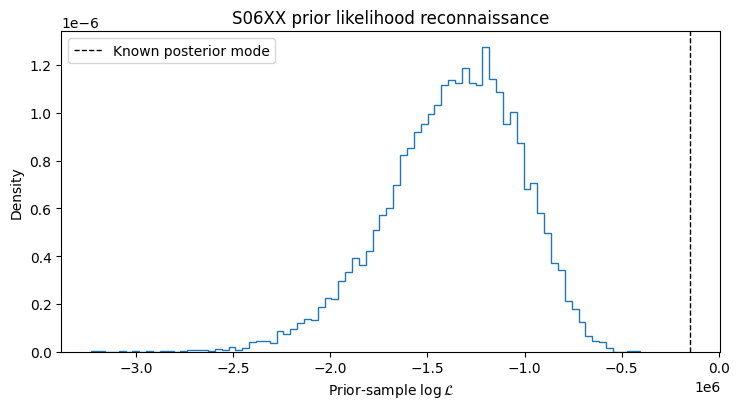

In [30]:
fig, ax = plt.subplots(
    figsize=(7.5, 4.2)
)

ax.hist(
    prior_logl,
    bins=80,
    histtype="step",
    density=True,
)

ax.axvline(
    known_source_logl,
    color="black",
    ls="--",
    lw=1.0,
    label="Known posterior mode",
)

ax.set_xlabel(
    r"Prior-sample $\log \mathcal{L}$"
)
ax.set_ylabel(
    "Density"
)
ax.set_title(
    f"{tilepol} prior likelihood reconnaissance"
)
ax.legend()

fig.tight_layout()
plt.show()

In [31]:
# -------------------------------------------------------------------------
# Diagnostic 2: construct a deliberately seeded two-mode live population.
#
# IMPORTANT:
# This is NOT a valid nested-sampling initial population and must never be
# used for evidence or posterior inference.
#
# Its sole purpose is to test whether the constrained slice kernel can
# maintain and rejuvenate the two known high-likelihood basins once they
# are explicitly represented.
# -------------------------------------------------------------------------

N_SEEDED_PER_MODE = 256

AMP_LOGRATIO_JITTER = 2.0e-3
PHASE_JITTER_DEG = 0.10
PHASE_JITTER_RAD = np.deg2rad(
    PHASE_JITTER_DEG
)

SEEDED_DIAGNOSTIC_SEED = 20_002


def jitter_mode_positions(
    rng_key,
    center,
    num_samples,
):
    """Generate small local perturbations around an NSS position."""
    amp_key, phase_key = jax.random.split(
        rng_key
    )

    center = jnp.asarray(
        center,
        dtype=jnp.float32,
    )

    amp_center = center[
        :N_AMPLITUDE_COORDS
    ]
    phase_center = center[
        N_AMPLITUDE_COORDS:
    ]

    amp = (
        amp_center[None, :]
        + AMP_LOGRATIO_JITTER
        * jax.random.normal(
            amp_key,
            shape=(
                num_samples,
                N_AMPLITUDE_COORDS,
            ),
            dtype=jnp.float32,
        )
    )

    phase = (
        phase_center[None, :]
        + PHASE_JITTER_RAD
        * jax.random.normal(
            phase_key,
            shape=(
                num_samples,
                N_PHASE_COORDS,
            ),
            dtype=jnp.float32,
        )
    )

    # Keep phases on the same fundamental interval.
    phase = (
        jnp.remainder(
            phase + jnp.pi,
            2.0 * jnp.pi,
        )
        - jnp.pi
    )

    return jnp.concatenate(
        [
            amp,
            phase,
        ],
        axis=1,
    )


seed_key = jax.random.key(
    SEEDED_DIAGNOSTIC_SEED
)

source_key, partner_key = jax.random.split(
    seed_key
)

seeded_source = jitter_mode_positions(
    source_key,
    source_map_position,
    N_SEEDED_PER_MODE,
)

seeded_partner = jitter_mode_positions(
    partner_key,
    partner_map_position,
    N_SEEDED_PER_MODE,
)

seeded_live = jnp.concatenate(
    [
        seeded_source,
        seeded_partner,
    ],
    axis=0,
)

seeded_logl = np.asarray(
    batched_loglikelihood(
        seeded_live
    )
)

print("Seeded diagnostic live set")
print("--------------------------")
print(
    "Shape:",
    seeded_live.shape,
)
print(
    "logL range:",
    f"{seeded_logl.min():.3f}",
    "to",
    f"{seeded_logl.max():.3f}",
)
print(
    "logL median:",
    f"{np.median(seeded_logl):.3f}",
)

Seeded diagnostic live set
--------------------------
Shape: (512, 30)
logL range: -146919.625 to -146574.016
logL median: -146682.406


In [32]:
# -------------------------------------------------------------------------
# Short, deliberately seeded NSS stress test.
# -------------------------------------------------------------------------

SEEDED_NUM_DELETE = 32
SEEDED_NUM_INNER_STEPS = 5
SEEDED_NUM_STEPS = 25

nss_seeded = blackjax.nss(
    logprior_fn=logprior_fn,
    loglikelihood_fn=loglikelihood_fn,
    num_inner_steps=SEEDED_NUM_INNER_STEPS,
    num_delete=SEEDED_NUM_DELETE,
)

nss_seeded_step = jax.jit(
    nss_seeded.step
)

seeded_state = nss_seeded.init(
    seeded_live
)

In [33]:
def live_symmetry_statistics(state):
    """Evaluate S(g) for the current NSS live set."""
    _, _, gains = jax.vmap(
        position_to_physical
    )(
        state.particles.position
    )

    return np.asarray(
        jax.vmap(
            symmetry_statistic
        )(
            gains
        )
    )


diagnostic_history = []

run_key = jax.random.key(
    20_003
)

for step_index in range(
    SEEDED_NUM_STEPS + 1
):
    live_logl = np.asarray(
        seeded_state.particles.loglikelihood
    )

    live_s = live_symmetry_statistics(
        seeded_state
    )

    diagnostic_history.append(
        {
            "step": step_index,
            "negative": int(
                np.sum(live_s < 0.0)
            ),
            "positive": int(
                np.sum(live_s > 0.0)
            ),
            "logl_min": float(
                live_logl.min()
            ),
            "logl_median": float(
                np.median(live_logl)
            ),
            "logl_max": float(
                live_logl.max()
            ),
        }
    )

    if (
        step_index % 5 == 0
        or step_index == SEEDED_NUM_STEPS
    ):
        row = diagnostic_history[-1]

        print(
            f"step={step_index:3d}  "
            f"S<0={row['negative']:3d}  "
            f"S>0={row['positive']:3d}  "
            f"logL_min={row['logl_min']:11.2f}  "
            f"logL_med={row['logl_median']:11.2f}  "
            f"logL_max={row['logl_max']:11.2f}"
        )

    if step_index == SEEDED_NUM_STEPS:
        break

    run_key, step_key = jax.random.split(
        run_key
    )

    seeded_state, seeded_info = (
        nss_seeded_step(
            step_key,
            seeded_state,
        )
    )

    jax.block_until_ready(
        seeded_state
    )

step=  0  S<0=256  S>0=256  logL_min= -146919.62  logL_med= -146682.41  logL_max= -146574.02
step=  5  S<0=263  S>0=249  logL_min= -146732.34  logL_med= -146670.48  logL_max= -146574.02
step= 10  S<0=259  S>0=253  logL_min= -146696.38  logL_med= -146659.83  logL_max= -146574.02
step= 15  S<0=259  S>0=253  logL_min= -146677.59  logL_med= -146651.53  logL_max= -146574.02
step= 20  S<0=267  S>0=245  logL_min= -146663.59  logL_med= -146643.78  logL_max= -146574.02
step= 25  S<0=264  S>0=248  logL_min= -146653.09  logL_med= -146637.03  logL_max= -146574.02


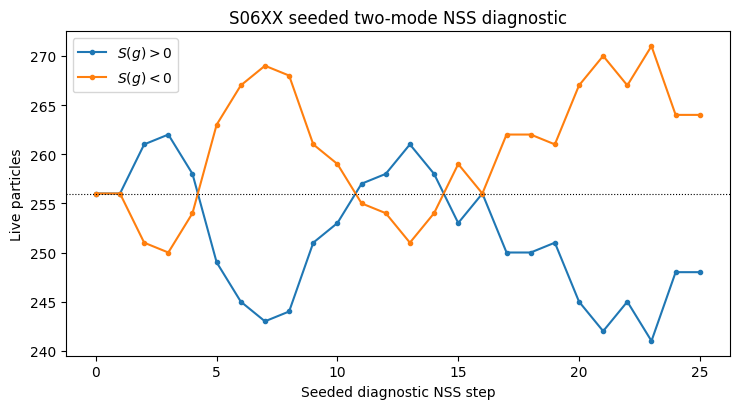

In [34]:
steps = np.asarray(
    [
        row["step"]
        for row in diagnostic_history
    ]
)

positive_counts = np.asarray(
    [
        row["positive"]
        for row in diagnostic_history
    ]
)

negative_counts = np.asarray(
    [
        row["negative"]
        for row in diagnostic_history
    ]
)

fig, ax = plt.subplots(
    figsize=(7.5, 4.2)
)

ax.plot(
    steps,
    positive_counts,
    marker="o",
    ms=3,
    label=r"$S(g)>0$",
)

ax.plot(
    steps,
    negative_counts,
    marker="o",
    ms=3,
    label=r"$S(g)<0$",
)

ax.axhline(
    N_SEEDED_PER_MODE,
    color="black",
    ls=":",
    lw=0.8,
)

ax.set_xlabel(
    "Seeded diagnostic NSS step"
)
ax.set_ylabel(
    "Live particles"
)
ax.set_title(
    f"{tilepol} seeded two-mode NSS diagnostic"
)
ax.legend()

fig.tight_layout()
plt.show()